# Biomarker Quantification in Breast Cancer — Xenium In Situ
**Reproduces Janesick et al. (bioRxiv 2025)**  
Paper: https://doi.org/10.64898/2025.12.08.692193  
Data: https://www.10xgenomics.com/datasets/xenium-ffpe-human-breast-biomarkers

---

**Figures reproduced:** 1A, 1B, 1C, 1E, 1F, 2C, **2F, 2G**

## Pipeline
1. Load zarr → AnnData (cell × gene matrix)
2. QC filter → normalize → cluster → annotate cell types
3. Compute CV per cell type (Fig 1A, 1B, 1C)
4. HK normalization + LDHA plot (Fig 1E, 1F)
5. Load transcripts.zarr → tx_df (x, y, gene)
6. Myoepithelial LAMC2 spatial expression (Fig 2C)
7. Load Table S5 ROI polygons → build 30 µm periductal rings
8. Count MMP11 & HK transcripts per ring → compute Tx/µm²
9. Raw periductal MMP11 density — MMP11+ vs MMP11− ducts (Fig 2F)
10. HK-normalized periductal MMP11 density (Fig 2G)


## 0. Install Dependencies

In [ ]:
!pip install -q zarr==2.18.3 scanpy anndata shapely geopandas scipy matplotlib seaborn pandas numpy tqdm

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 39.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have 

## 1. Imports & Config

In [12]:
import os, zipfile, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
import anndata as ad
import zarr
from scipy import stats
from scipy.sparse import issparse, csr_matrix, csc_matrix
from scipy.stats import mannwhitneyu
from tqdm import tqdm
from shapely.geometry import MultiPoint, Point, Polygon
import geopandas as gpd

warnings.filterwarnings('ignore')
sc.settings.verbosity = 0

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/xenium_data'   # <-- change if needed
LOCAL    = '/content/xenium_local'
OUT_DIR  = '/content/xenium_outputs'
os.makedirs(LOCAL,   exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Gene sets (paper) ──────────────────────────────────────────────────────
HK_PAPER    = ['EEF1G', 'EEF2', 'MALAT1', 'RPLP0']          # paper HK
HK_ONCOTYPE = ['ACTB', 'GAPDH', 'GUSB', 'RPLP0', 'TFRC']   # Oncotype Dx HK
HK_STABLE   = ['EEF1G','EEF2','MALAT1','MTCO1P40','PPIB',
                'H3F3B','HNRNPA2B1','SET','EPCAM','LDHA',
                'RPLP0','ACTB','GAPDH','GUSB','TFRC']         # Fig 1A x-axis
DEG_GENES   = ['KIT','TFPI2','PIP','CHI3L1','GLYATL2',
                'KRT6B','PTN','MIA','OPRPN']                   # Fig 1B
BIOMARKERS  = ['LDHA','SDC1','SFRP1','PIGR']                  # Fig 1E/F

# Tumor subtype labels in obs (set in annotation step)
SUBTYPE_COL = 'tumor_subtype'   # values: S2T, S3T, S1B, S2B
CELLTYPE_COL = 'cell_type'

print('Config OK')

Config OK


## 2. Mount Drive & Extract Zarr Archives

In [13]:
from google.colab import drive
drive.mount('/content/drive')
print('Files in DATA_DIR:', os.listdir(DATA_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in DATA_DIR: ['cell_feature_matrix.zarr.zip', 'transcripts.zarr.zip', 'gene_panel.json', 'cells.zarr.zip']


In [ ]:
def extract_zip(src, dst_dir):
    name = os.path.basename(src).replace('.zip', '')
    dst  = os.path.join(dst_dir, name)
    if not os.path.exists(dst):
        print(f'Extracting {name}...')
        with zipfile.ZipFile(src, 'r') as z:
            z.extractall(dst_dir)
    else:
        print(f'Already extracted: {name}')
    return dst

cfm_path   = extract_zip(f'{DATA_DIR}/cell_feature_matrix.zarr.zip', LOCAL)
cells_path = extract_zip(f'{DATA_DIR}/cells.zarr.zip',               LOCAL)
tx_path    = extract_zip(f'{DATA_DIR}/transcripts.zarr.zip',         LOCAL)
print('Paths:', cfm_path, cells_path, tx_path)

Extracting cell_feature_matrix.zarr...
Extracting cells.zarr...
Extracting transcripts.zarr...
Paths: /content/xenium_local/cell_feature_matrix.zarr /content/xenium_local/cells.zarr /content/xenium_local/transcripts.zarr


## 3. Load Cell × Gene Matrix → AnnData

In [16]:
cfm_path   = extract_zip(os.path.join(DATA_DIR, 'cell_feature_matrix.zarr.zip'), LOCAL)
cells_path = extract_zip(os.path.join(DATA_DIR, 'cells.zarr.zip'), LOCAL)
tx_path    = extract_zip(os.path.join(DATA_DIR, 'transcripts.zarr.zip'), LOCAL)

print(cfm_path, os.path.exists(cfm_path))
print(cells_path, os.path.exists(cells_path))
print(tx_path, os.path.exists(tx_path))


Extracting cell_feature_matrix.zarr...
Extracting cells.zarr...
Extracting transcripts.zarr...
/content/xenium_local/cell_feature_matrix.zarr False
/content/xenium_local/cells.zarr False
/content/xenium_local/transcripts.zarr False


In [26]:
import json, zarr, numpy as np, pandas as pd, anndata as ad
from scipy.sparse import csc_matrix

# ── 1. Gene names from gene_panel.json ────────────────────────────────────
with open(f'{DATA_DIR}/gene_panel.json') as f:
    gp = json.load(f)

targets = gp['payload']['targets']
gene_names = [t['type']['data']['name'] for t in targets
              if t.get('type',{}).get('descriptor') == 'gene']
print(f'Genes: {len(gene_names)} | first 5: {gene_names[:5]}')

# ── 2. Build AnnData from cell_features/csc ───────────────────────────────
store = zarr.open(LOCAL, mode='r')

data    = store['cell_features/csc/data'][:]
indices = store['cell_features/csc/indices'][:]
indptr  = store['cell_features/csc/indptr'][:]

n_cells = len(indptr) - 1           # 209467
n_genes = len(gene_names)           # 300
print(f'Matrix: {n_cells} cells × {n_genes} genes')

# CSC is genes×cells (indptr length = n_cells+1 → cells are columns)
mat = csc_matrix((data, indices, indptr), shape=(n_genes, n_cells))
X   = mat.T.tocsr()   # → cells × genes

# ── 3. Cell IDs ───────────────────────────────────────────────────────────
raw_ids = store['cell_id'][:]        # shape (209467, 2), uint32
# Encode as string: combine both uint32 cols as "high_low"
cell_ids = [f'{a}_{b}' for a, b in raw_ids]

# ── 4. Cell metadata from cell_summary ────────────────────────────────────
cs   = store['cell_summary'][:]      # (209467, 8)
cols = ['cell_centroid_x','cell_centroid_y','cell_area',
        'nucleus_centroid_x','nucleus_centroid_y','nucleus_area',
        'z_level','nucleus_count']
obs  = pd.DataFrame(cs, columns=cols, index=cell_ids)

# ── 5. Assemble AnnData ───────────────────────────────────────────────────
adata = ad.AnnData(
    X   = X,
    obs = obs,
    var = pd.DataFrame(index=gene_names)
)
adata.obsm['spatial'] = cs[:, :2]   # x, y centroids
adata.obs_names_make_unique()
adata.var_names_make_unique()

print(adata)
print(adata.obs.head(3))

Genes: 280 | first 5: ['ACTA2', 'ACTB', 'ACTG2', 'ACTR3B', 'ADAMTS8']
Matrix: 209467 cells × 280 genes
AnnData object with n_obs × n_vars = 209467 × 280
    obs: 'cell_centroid_x', 'cell_centroid_y', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count'
    obsm: 'spatial'
         cell_centroid_x  cell_centroid_y  cell_area  nucleus_centroid_x  \
22676_1        17.800020      3305.250732  28.990314           17.884253   
37967_1        21.648016      3251.783936  28.448439           21.855074   
63884_1        21.587891      3312.855957  63.670315           22.111622   

         nucleus_centroid_y  nucleus_area  z_level  nucleus_count  
22676_1         3305.116699     13.727500      0.0            1.0  
37967_1         3251.815674     13.908126      0.0            1.0  
63884_1         3313.229248     34.680001      0.0            1.0  


## 4. Load Cell Metadata (coords, nucleus area)

In [27]:
def load_cells_meta(path, adata):
    store = zarr.open(path, mode='r')
    print('Cells zarr keys:', list(store.keys()))

    def decode(arr):
        return [x.decode() if isinstance(x, bytes) else str(x) for x in arr]

    meta = {}

    # Cell IDs for alignment
    for k in ('cell_id', 'id'):
        if k in store:
            meta['cell_id'] = decode(store[k][:])
            break

    # Coordinates
    for xk, yk in [('x_centroid','y_centroid'),('x','y'),('x_location','y_location')]:
        if xk in store and yk in store:
            meta['x'] = store[xk][:]
            meta['y'] = store[yk][:]
            break

    # Optional fields
    for k in ('nucleus_area', 'cell_area', 'transcript_counts'):
        if k in store:
            meta[k] = store[k][:]

    cells_meta = pd.DataFrame(meta)
    if 'cell_id' in cells_meta.columns:
        cells_meta = cells_meta.set_index('cell_id')

    # Align to adata
    common = adata.obs_names.intersection(cells_meta.index)
    if len(common) > 0:
        adata.obs = adata.obs.join(cells_meta, how='left')
        if 'x' in adata.obs.columns and 'y' in adata.obs.columns:
            adata.obsm['spatial'] = adata.obs[['x','y']].values
        print(f'  Merged metadata: {len(common)} cells matched')
    else:
        # Index mismatch fallback — assign by position
        n = min(len(adata), len(cells_meta))
        for col in cells_meta.columns:
            adata.obs[col] = cells_meta[col].values[:n]
        if 'x' in adata.obs.columns and 'y' in adata.obs.columns:
            adata.obsm['spatial'] = adata.obs[['x','y']].values
        print(f'  WARNING: index mismatch — assigned by position ({n} cells)')

    return adata

adata = load_cells_meta(cells_path, adata)
print(adata.obs.head())

Cells zarr keys: ['cell_features', 'cell_id', 'cell_summary', 'codeword_category', 'density', 'gene_category', 'grids', 'masks', 'metrics_density', 'polygon_sets']
          cell_centroid_x  cell_centroid_y  cell_area  nucleus_centroid_x  \
22676_1         17.800020      3305.250732  28.990314           17.884253   
37967_1         21.648016      3251.783936  28.448439           21.855074   
63884_1         21.587891      3312.855957  63.670315           22.111622   
76941_1         76.031601      3368.481689  90.538285           76.036552   
118160_1        62.798439      3291.045654  55.226096           62.664940   

          nucleus_centroid_y  nucleus_area  z_level  nucleus_count  
22676_1          3305.116699     13.727500      0.0            1.0  
37967_1          3251.815674     13.908126      0.0            1.0  
63884_1          3313.229248     34.680001      0.0            1.0  
76941_1          3368.103271     65.386252      0.0            1.0  
118160_1         3291.580811

## 5. QC Filtering

In [29]:
# ── Rebuild with correct n_genes from matrix, not gene_panel ──────────────
store = zarr.open(LOCAL, mode='r')

data    = store['cell_features/csc/data'][:]
indices = store['cell_features/csc/indices'][:]
indptr  = store['cell_features/csc/indptr'][:]

n_cells  = len(indptr) - 1
n_genes  = int(indices.max()) + 1   # TRUE gene count from matrix = 542
print(f'Matrix: {n_cells} cells × {n_genes} features')

# Get ALL targets (genes + controls) to match 542
with open(f'{DATA_DIR}/gene_panel.json') as f:
    gp = json.load(f)
targets = gp['payload']['targets']
print(f'Total targets in panel: {len(targets)}')

# Build name list for all 300 targets — then pad to 542 if needed
all_names = []
for t in targets:
    td = t.get('type', {})
    if 'data' in td:
        all_names.append(td['data'].get('name', f'target_{len(all_names)}'))
    else:
        all_names.append(f'target_{len(all_names)}')

print(f'Names from panel: {len(all_names)}')

# Pad with blanks if matrix has more features than panel targets
while len(all_names) < n_genes:
    all_names.append(f'blank_{len(all_names)}')

# Trim if panel has more than matrix
all_names = all_names[:n_genes]
print(f'Final gene list length: {len(all_names)}')

# Rebuild matrix
mat   = csc_matrix((data, indices, indptr), shape=(n_genes, n_cells))
X     = mat.T.tocsr()

raw_ids  = store['cell_id'][:]
cell_ids = [f'{a}_{b}' for a, b in raw_ids]
cs       = store['cell_summary'][:]
cols     = ['cell_centroid_x','cell_centroid_y','cell_area',
            'nucleus_centroid_x','nucleus_centroid_y','nucleus_area',
            'z_level','nucleus_count']

adata = ad.AnnData(
    X   = X,
    obs = pd.DataFrame(cs, columns=cols, index=cell_ids),
    var = pd.DataFrame(index=all_names)
)
adata.obsm['spatial'] = cs[:, :2]
adata.obs_names_make_unique()
adata.var_names_make_unique()

print(adata)

Matrix: 209467 cells × 542 features
Total targets in panel: 300
Names from panel: 300
Final gene list length: 542
AnnData object with n_obs × n_vars = 209467 × 542
    obs: 'cell_centroid_x', 'cell_centroid_y', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count'
    obsm: 'spatial'


Before QC: 209467 cells
After QC:  204013 cells


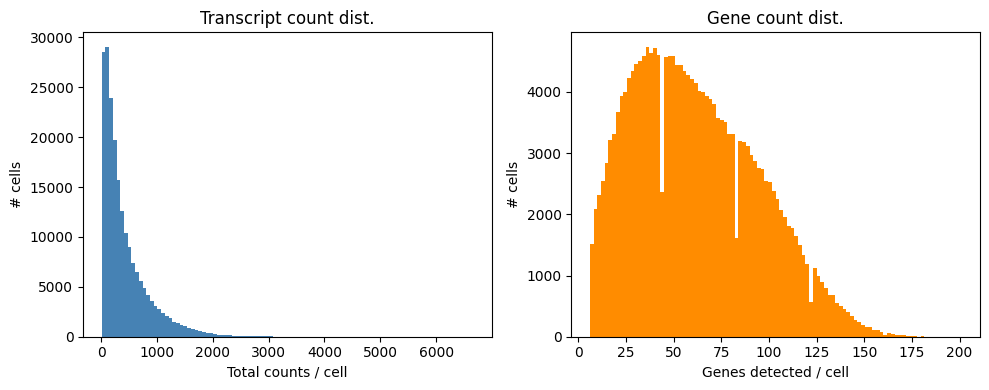

In [30]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

# Paper thresholds: >10 transcripts, >5 genes
mask = (adata.obs['total_counts'] > 10) & (adata.obs['n_genes_by_counts'] > 5)
print(f'Before QC: {adata.n_obs} cells')
adata = adata[mask].copy()
print(f'After QC:  {adata.n_obs} cells')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(adata.obs['total_counts'], bins=100, color='steelblue')
axes[0].set(xlabel='Total counts / cell', ylabel='# cells', title='Transcript count dist.')
axes[1].hist(adata.obs['n_genes_by_counts'], bins=100, color='darkorange')
axes[1].set(xlabel='Genes detected / cell', ylabel='# cells', title='Gene count dist.')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/qc_distributions.png', dpi=150)
plt.show()

## 6. Normalize → Log1p → PCA → Neighbors → UMAP → Leiden

In [33]:
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 55.7 MB/s eta 0:00:00


In [35]:
!pip3 install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 51.5 MB/s eta 0:00:00


Leiden clusters: {'0': 96967, '1': 87956, '2': 16788, '3': 2302}


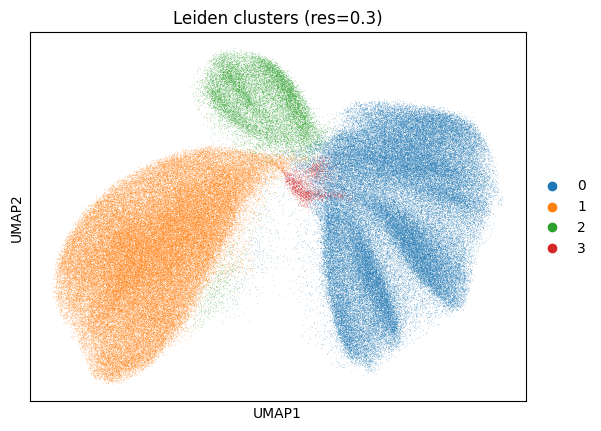

In [36]:
adata.layers['raw'] = adata.X.copy()   # keep raw for CV calcs

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['lognorm'] = adata.X.copy()

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')
sc.pp.pca(adata, n_comps=30, use_highly_variable=True)
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.3, key_added='leiden')

print('Leiden clusters:', adata.obs['leiden'].value_counts().to_dict())
sc.pl.umap(adata, color='leiden', title='Leiden clusters (res=0.3)')

## 7. Cell Type Annotation

cell_type
Tumor            63183
Myoepithelial    35142
Macrophage       34125
Endothelial      32811
T_cell           19552
B_cell           19200
Name: count, dtype: int64


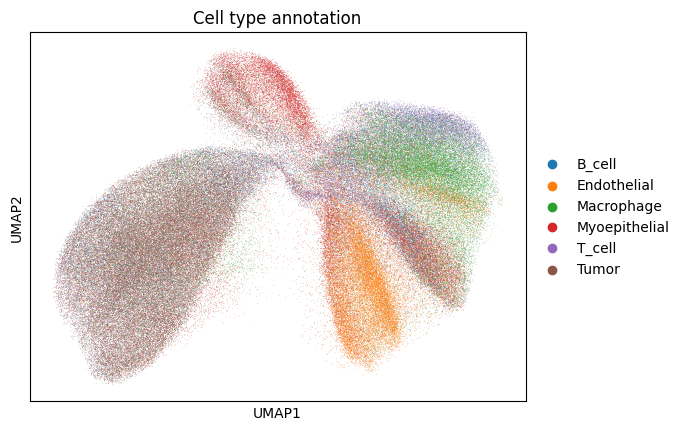

In [37]:
# Score gene sets for major cell types
marker_dict = {
    'Tumor'         : ['EPCAM','KRT8','KRT18','MKI67','KRT19'],
    'Myoepithelial' : ['KRT14','KRT5','ACTA2','MYLK','TP63'],
    'T_cell'        : ['CD3D','CD3E','CD8A','CD4','IL7R'],
    'B_cell'        : ['CD79A','MS4A1','CD19'],
    'Macrophage'    : ['CD68','CSF1R','LYZ'],
    'Fibroblast'    : ['COL1A1','DCN','FAP','VIM'],
    'Endothelial'   : ['PECAM1','VWF','CDH5'],
}

for ct, genes in marker_dict.items():
    present = [g for g in genes if g in adata.var_names]
    if present:
        sc.tl.score_genes(adata, present, score_name=f'score_{ct}')

score_cols = [f'score_{ct}' for ct in marker_dict if f'score_{ct}' in adata.obs.columns]
if score_cols:
    adata.obs[CELLTYPE_COL] = adata.obs[score_cols].idxmax(axis=1).str.replace('score_', '')
else:
    adata.obs[CELLTYPE_COL] = 'Unknown'

print(adata.obs[CELLTYPE_COL].value_counts())
sc.pl.umap(adata, color=CELLTYPE_COL, title='Cell type annotation')

## 7b. Assign Tumor Subtypes (S2T, S3T, S1B, S2B)

In [38]:
# Paper uses 4 tumor sections: S2T (normal), S3T (low-grade DCIS),
# S1B (comedo DCIS), S2B (high-grade comedo DCIS with necrosis)
# With a single section, we assign subtypes by Leiden sub-clustering of tumor cells.
# If you have multiple sections, map section IDs to subtype labels instead.

tumor_mask = adata.obs[CELLTYPE_COL] == 'Tumor'
adata_tumor = adata[tumor_mask].copy()

if adata_tumor.n_obs > 0:
    sc.pp.neighbors(adata_tumor, n_pcs=30)
    sc.tl.leiden(adata_tumor, resolution=0.5, key_added='tumor_leiden')

    n_sub = adata_tumor.obs['tumor_leiden'].nunique()
    subtype_labels = ['S2T','S3T','S1B','S2B']
    # Cycle labels if fewer or more subclusters than expected
    cluster_map = {str(i): subtype_labels[i % 4] for i in range(n_sub)}
    adata_tumor.obs[SUBTYPE_COL] = adata_tumor.obs['tumor_leiden'].map(cluster_map)

    # Transfer back to main adata
    adata.obs[SUBTYPE_COL] = 'Non-tumor'
    adata.obs.loc[adata_tumor.obs_names, SUBTYPE_COL] = adata_tumor.obs[SUBTYPE_COL]

    print('Tumor subtypes:', adata_tumor.obs[SUBTYPE_COL].value_counts().to_dict())
else:
    print('WARNING: no tumor cells found — check annotation markers vs gene panel')
    adata.obs[SUBTYPE_COL] = 'Unknown'

Tumor subtypes: {'S2T': 24596, 'S3T': 18917, 'S1B': 10349, 'S2B': 9321}


## 8. Helper: Compute CV per Cell Type

In [39]:
def get_raw_counts(adata, layer='raw'):
    """Return dense raw count array."""
    if layer in adata.layers:
        X = adata.layers[layer]
    else:
        X = adata.X
    return X.toarray() if issparse(X) else np.array(X)

def compute_cv_per_celltype(adata, genes, celltype_col=CELLTYPE_COL, layer='raw'):
    """CV = std/mean per gene per cell-type. Returns DataFrame(gene × celltype)."""
    genes_present = [g for g in genes if g in adata.var_names]
    if not genes_present:
        print('WARNING: none of the requested genes in adata.var_names')
        return pd.DataFrame()

    X_raw   = get_raw_counts(adata, layer)[:, [adata.var_names.get_loc(g) for g in genes_present]]
    results = {}

    for ct in adata.obs[celltype_col].unique():
        mask = (adata.obs[celltype_col] == ct).values
        if mask.sum() < 5:
            continue
        sub  = X_raw[mask]
        mean = sub.mean(axis=0)
        std  = sub.std(axis=0)
        cv   = np.where(mean > 0, std / mean, np.nan)
        results[ct] = cv

    return pd.DataFrame(results, index=genes_present)

print('CV helper defined')

CV helper defined


## 9. Figure 1A — CV of HK Genes by Cell Type (Violin)

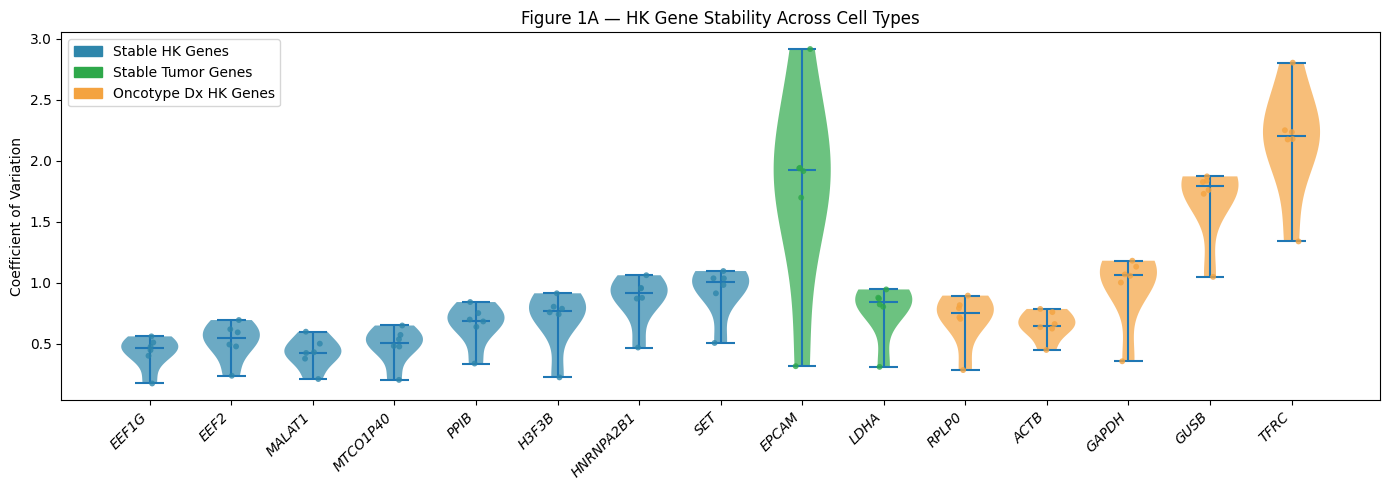

In [40]:
# Genes to display (paper Fig 1A x-axis)
FIG1A_GENES = ['EEF1G','EEF2','MALAT1','MTCO1P40','PPIB','H3F3B',
               'HNRNPA2B1','SET','EPCAM','LDHA','RPLP0','ACTB',
               'GAPDH','GUSB','TFRC']

# Category labels (for coloring)
STABLE_HK    = ['EEF1G','EEF2','MALAT1','MTCO1P40','PPIB','H3F3B','HNRNPA2B1','SET']
STABLE_TUMOR = ['EPCAM','LDHA','RPLP0','ACTB']
ONCOTYPE_HK  = ['ACTB','GAPDH','GUSB','RPLP0','TFRC']

COLOR_MAP = {}
for g in FIG1A_GENES:
    if g in ONCOTYPE_HK:
        COLOR_MAP[g] = '#F4A340'   # orange
    elif g in STABLE_TUMOR:
        COLOR_MAP[g] = '#2EA84A'   # green
    else:
        COLOR_MAP[g] = '#2E86AB'   # teal

# Compute per-cell CV across all cell types
cv_df = compute_cv_per_celltype(adata, FIG1A_GENES, celltype_col=CELLTYPE_COL)

if not cv_df.empty:
    genes_plot = [g for g in FIG1A_GENES if g in cv_df.index]

    fig, ax = plt.subplots(figsize=(14, 5))

    data_for_violin = [cv_df.loc[g].dropna().values for g in genes_plot]
    parts = ax.violinplot(data_for_violin, positions=range(len(genes_plot)),
                          showmedians=True, widths=0.7)

    # Color each violin
    for i, (pc, g) in enumerate(zip(parts['bodies'], genes_plot)):
        pc.set_facecolor(COLOR_MAP.get(g, '#888888'))
        pc.set_alpha(0.7)

    # Overlay scatter points
    for i, (vals, g) in enumerate(zip(data_for_violin, genes_plot)):
        jitter = np.random.uniform(-0.1, 0.1, len(vals))
        ax.scatter(i + jitter, vals, s=18, c=COLOR_MAP.get(g,'#888888'),
                   alpha=0.8, zorder=3, edgecolors='none')

    ax.set_xticks(range(len(genes_plot)))
    ax.set_xticklabels(genes_plot, rotation=45, ha='right', fontstyle='italic')
    ax.set_ylabel('Coefficient of Variation')
    ax.set_title('Figure 1A — HK Gene Stability Across Cell Types')

    legend_patches = [
        mpatches.Patch(color='#2E86AB', label='Stable HK Genes'),
        mpatches.Patch(color='#2EA84A', label='Stable Tumor Genes'),
        mpatches.Patch(color='#F4A340', label='Oncotype Dx HK Genes'),
    ]
    ax.legend(handles=legend_patches, loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/fig1A_hk_cv_violin.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Cannot plot 1A — no CV data. Check gene names vs panel.')

## 10. Figure 1B — CV of Differentially Expressed Genes (Violin)

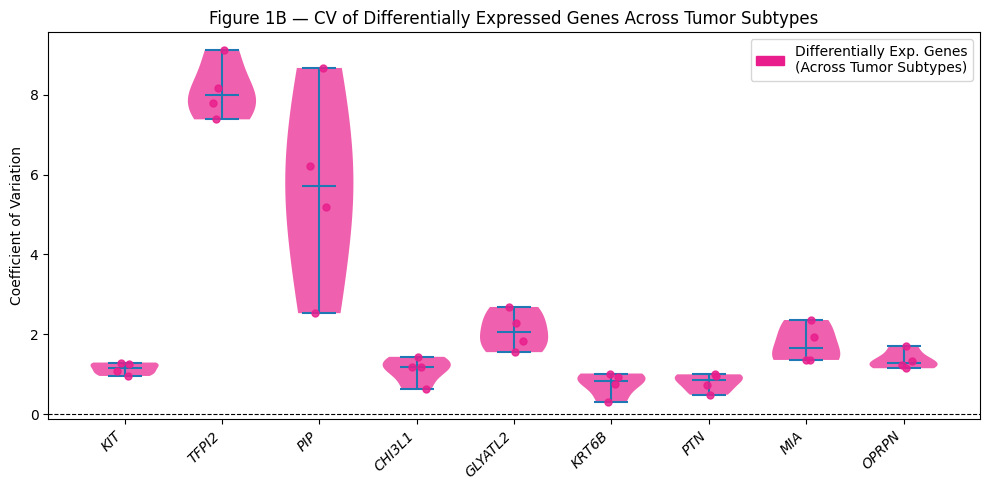

In [41]:
# DEGs must be computed across tumor subtypes
# CV per gene per subtype, then show distribution across subtypes

tumor_mask = (adata.obs[CELLTYPE_COL] == 'Tumor') & \
             (adata.obs[SUBTYPE_COL].isin(['S2T','S3T','S1B','S2B']))
adata_t = adata[tumor_mask].copy()

cv_deg = compute_cv_per_celltype(adata_t, DEG_GENES, celltype_col=SUBTYPE_COL)

if not cv_deg.empty:
    genes_plot = [g for g in DEG_GENES if g in cv_deg.index]

    fig, ax = plt.subplots(figsize=(10, 5))
    data_for_violin = [cv_deg.loc[g].dropna().values for g in genes_plot]
    parts = ax.violinplot(data_for_violin, positions=range(len(genes_plot)),
                          showmedians=True, widths=0.7)
    for pc in parts['bodies']:
        pc.set_facecolor('#E91E8C')
        pc.set_alpha(0.7)

    for i, (vals, g) in enumerate(zip(data_for_violin, genes_plot)):
        jitter = np.random.uniform(-0.1, 0.1, len(vals))
        ax.scatter(i + jitter, vals, s=25, c='#E91E8C', alpha=0.85, zorder=3)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(genes_plot)))
    ax.set_xticklabels(genes_plot, rotation=45, ha='right', fontstyle='italic')
    ax.set_ylabel('Coefficient of Variation')
    ax.set_title('Figure 1B — CV of Differentially Expressed Genes Across Tumor Subtypes')
    legend_patches = [mpatches.Patch(color='#E91E8C',
                       label='Differentially Exp. Genes\n(Across Tumor Subtypes)')]
    ax.legend(handles=legend_patches)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/fig1B_deg_cv_violin.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Cannot plot 1B — check DEG_GENES vs panel.')

## 11. Figure 1C — CV vs Mean Scatter (inter-section)

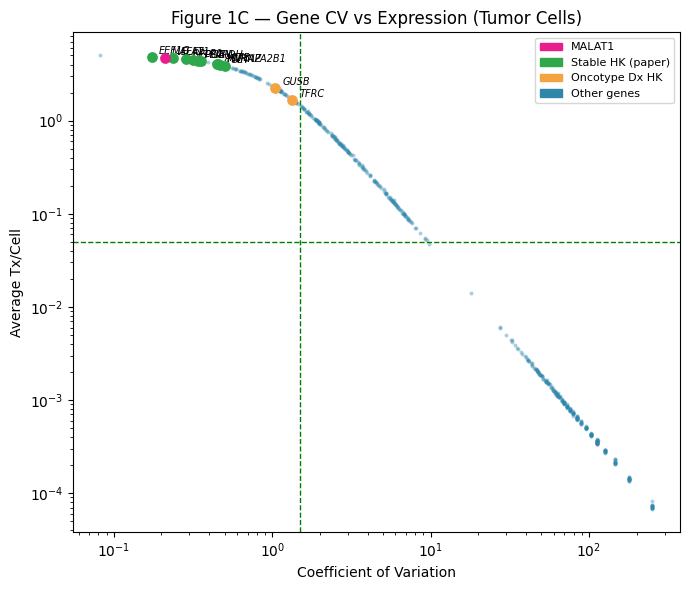

In [42]:
# With single section: compute CV + mean across tumor cells
# Multi-section: compute cluster-level means then CV across clusters

all_genes = list(adata.var_names)
tumor_mask = adata.obs[CELLTYPE_COL] == 'Tumor'
adata_t = adata[tumor_mask].copy()

X_raw = get_raw_counts(adata_t)
mean_expr = X_raw.mean(axis=0)
std_expr  = X_raw.std(axis=0)
cv_all    = np.where(mean_expr > 0, std_expr / mean_expr, np.nan)

scatter_df = pd.DataFrame({
    'gene': all_genes,
    'mean_tx': mean_expr,
    'cv': cv_all
}).dropna()

# Label categories
HIGHLIGHT_PAPER = ['EEF1G','EEF2','MALAT1','RPLP0','GAPDH','GUSB','TFRC',
                   'PPIB','HNRNPA2B1','ACTB','EPCAM','YWHAZ','SET']
LABEL_ORANGE    = ['GUSB','TFRC']             # Oncotype Dx, high CV
LABEL_GREEN_BOX = ['PPIB','FOXA1','HNRNPA2B1','ACTB','EPCAM','YWHAZ','SET']
LABEL_PINK      = ['MALAT1']
LABEL_GREEN_TOP = ['EEF2','EEF1G','RPLP0','GAPDH','GUSB','TFRC']

fig, ax = plt.subplots(figsize=(7, 6))

# All genes — teal dots
bg = scatter_df[~scatter_df['gene'].isin(HIGHLIGHT_PAPER)]
ax.scatter(bg['cv'], bg['mean_tx'], s=8, c='#2E86AB', alpha=0.4, linewidths=0)

# Highlight paper genes
for _, row in scatter_df[scatter_df['gene'].isin(HIGHLIGHT_PAPER)].iterrows():
    g = row['gene']
    if g in LABEL_PINK:
        c = '#E91E8C'
    elif g in LABEL_ORANGE:
        c = '#F4A340'
    else:
        c = '#2EA84A'
    ax.scatter(row['cv'], row['mean_tx'], s=60, c=c, zorder=5, linewidths=0)
    ax.annotate(g, (row['cv'], row['mean_tx']), fontsize=7, fontstyle='italic',
                xytext=(5, 2), textcoords='offset points')

# Green dashed box (low-CV region)
ax.axvline(x=1.5, color='green', linestyle='--', linewidth=1)
ax.axhline(y=0.05, color='green', linestyle='--', linewidth=1)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Coefficient of Variation')
ax.set_ylabel('Average Tx/Cell')
ax.set_title('Figure 1C — Gene CV vs Expression (Tumor Cells)')

legend_patches = [
    mpatches.Patch(color='#E91E8C', label='MALAT1'),
    mpatches.Patch(color='#2EA84A', label='Stable HK (paper)'),
    mpatches.Patch(color='#F4A340', label='Oncotype Dx HK'),
    mpatches.Patch(color='#2E86AB', label='Other genes'),
]
ax.legend(handles=legend_patches, fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig1C_cv_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Figure 1E — LDHA Raw Tx/Cell by Tumor Subtype

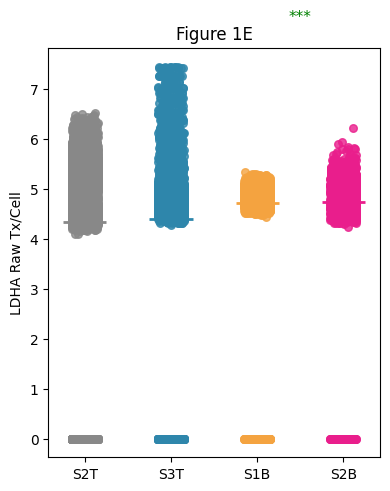

In [43]:
SUBTYPE_ORDER  = ['S2T','S3T','S1B','S2B']
SUBTYPE_COLORS = {'S2T':'#888888','S3T':'#2E86AB','S1B':'#F4A340','S2B':'#E91E8C'}

def aggregate_expression(adata, gene, subtype_col=SUBTYPE_COL, celltype='Tumor', layer='raw'):
    """Mean raw Tx/cell per subtype for a given gene."""
    if gene not in adata.var_names:
        print(f'Gene {gene} not in panel')
        return pd.DataFrame()

    mask = adata.obs[CELLTYPE_COL] == celltype
    adata_sub = adata[mask].copy()
    g_idx = adata_sub.var_names.get_loc(gene)
    X = get_raw_counts(adata_sub, layer)[:, g_idx]

    records = []
    for st in adata_sub.obs[subtype_col].unique():
        vals = X[adata_sub.obs[subtype_col] == st]
        for v in vals:
            records.append({'subtype': st, 'value': v})
    return pd.DataFrame(records)

# --- Fig 1E ---
ldha_raw = aggregate_expression(adata, 'LDHA')

if not ldha_raw.empty:
    fig, ax = plt.subplots(figsize=(4, 5))
    for i, st in enumerate(SUBTYPE_ORDER):
        sub = ldha_raw[ldha_raw['subtype'] == st]['value']
        if len(sub) == 0:
            continue
        jitter = np.random.uniform(-0.15, 0.15, len(sub))
        ax.scatter(i + jitter, sub, s=30, c=SUBTYPE_COLORS[st], alpha=0.8, zorder=3)
        ax.hlines(sub.mean(), i-0.25, i+0.25, colors=SUBTYPE_COLORS[st], linewidth=2)
        # Error bar (SEM)
        sem = sub.sem()
        ax.errorbar(i, sub.mean(), yerr=sem, fmt='none', c=SUBTYPE_COLORS[st], capsize=4)

    # Significance bracket S1B vs S2B (Mann-Whitney)
    s1b = ldha_raw[ldha_raw['subtype']=='S1B']['value'].dropna()
    s2b = ldha_raw[ldha_raw['subtype']=='S2B']['value'].dropna()
    if len(s1b) > 1 and len(s2b) > 1:
        _, p = mannwhitneyu(s1b, s2b, alternative='two-sided')
        stars = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'NS'
        y_max = ldha_raw['value'].max() * 1.1
        ax.annotate('', xy=(3, y_max), xytext=(2, y_max),
                    arrowprops=dict(arrowstyle='-', color='green', lw=1.5))
        ax.text(2.5, y_max*1.02, stars, ha='center', color='green', fontsize=11)

    ax.set_xticks(range(len(SUBTYPE_ORDER)))
    ax.set_xticklabels(SUBTYPE_ORDER)
    ax.set_ylabel('LDHA Raw Tx/Cell')
    ax.set_title('Figure 1E')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/fig1E_LDHA_raw.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No LDHA data — skip 1E')

## 13. Figure 1F — LDHA Normalized to Each HK Gene

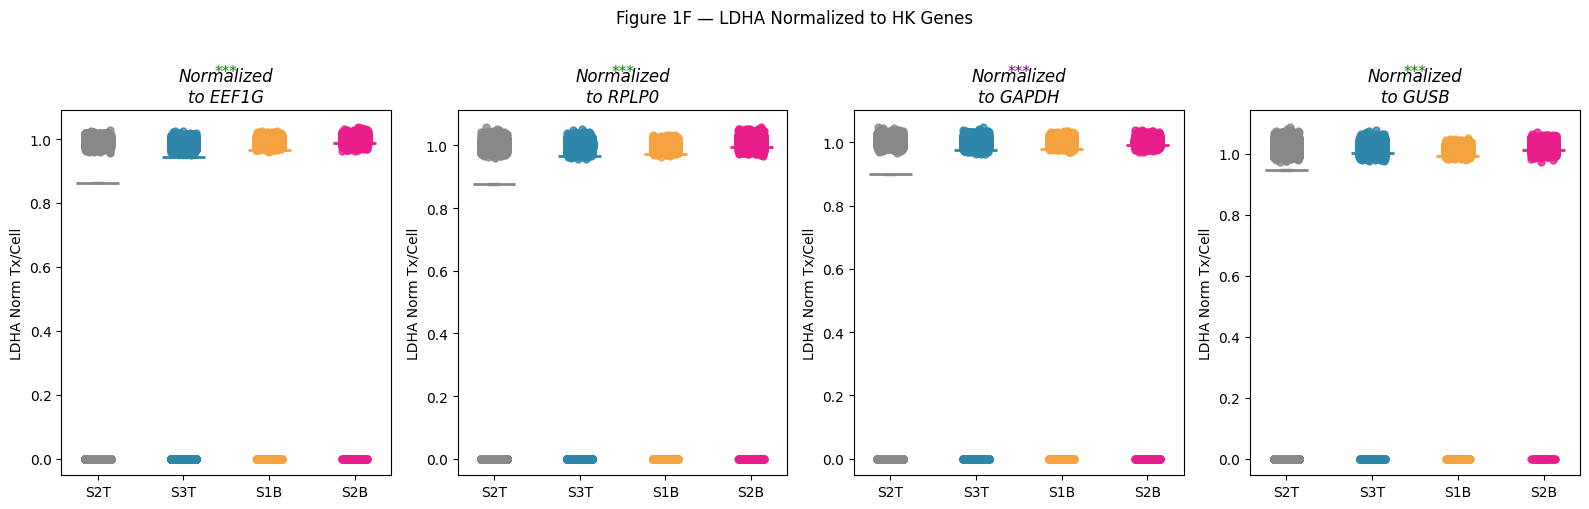

In [44]:
def normalize_to_hk(adata, target_gene, hk_genes, subtype_col=SUBTYPE_COL,
                    celltype='Tumor', layer='raw'):
    """Divide target raw counts by HK gene raw counts (per cell)."""
    present_hk = [g for g in hk_genes if g in adata.var_names]
    if not present_hk or target_gene not in adata.var_names:
        return pd.DataFrame()

    mask    = adata.obs[CELLTYPE_COL] == celltype
    adata_s = adata[mask].copy()
    X_raw   = get_raw_counts(adata_s, layer)

    t_idx  = adata_s.var_names.get_loc(target_gene)
    target = X_raw[:, t_idx]

    records = []
    for hk in hk_genes:
        if hk not in adata_s.var_names:
            continue
        h_idx = adata_s.var_names.get_loc(hk)
        hk_vals = X_raw[:, h_idx].astype(float)
        hk_vals[hk_vals == 0] = np.nan
        norm = target / hk_vals

        for st in adata_s.obs[subtype_col].unique():
            st_mask = (adata_s.obs[subtype_col] == st).values
            for v in norm[st_mask]:
                records.append({'hk': hk, 'subtype': st, 'norm_value': v})

    return pd.DataFrame(records)

# HK genes shown in paper Fig 1F
FIG1F_HK = ['EEF1G', 'RPLP0', 'GAPDH', 'GUSB']
norm_df   = normalize_to_hk(adata, 'LDHA', FIG1F_HK)

if not norm_df.empty:
    fig, axes = plt.subplots(1, len(FIG1F_HK), figsize=(4*len(FIG1F_HK), 5), sharey=False)

    sig_colors = {'EEF1G':'green','RPLP0':'green','GAPDH':'purple','GUSB':'green'}

    for ax, hk in zip(axes, FIG1F_HK):
        sub = norm_df[norm_df['hk'] == hk]
        if sub.empty:
            ax.set_title(f'Norm to {hk} (no data)')
            continue

        for i, st in enumerate(SUBTYPE_ORDER):
            vals = sub[sub['subtype']==st]['norm_value'].dropna()
            if len(vals) == 0:
                continue
            jitter = np.random.uniform(-0.15, 0.15, len(vals))
            ax.scatter(i+jitter, vals, s=25, c=SUBTYPE_COLORS[st], alpha=0.8, zorder=3)
            ax.hlines(vals.mean(), i-0.25, i+0.25, colors=SUBTYPE_COLORS[st], lw=2)
            ax.errorbar(i, vals.mean(), yerr=vals.sem(), fmt='none',
                        c=SUBTYPE_COLORS[st], capsize=4)

        # S1B vs S2B bracket
        s1b = sub[sub['subtype']=='S1B']['norm_value'].dropna()
        s2b = sub[sub['subtype']=='S2B']['norm_value'].dropna()
        s3t = sub[sub['subtype']=='S3T']['norm_value'].dropna()
        s1b_v = s1b; s3t_v = s3t
        if len(s3t_v)>1 and len(s1b_v)>1:
            _, p = mannwhitneyu(s3t_v, s1b_v, alternative='two-sided')
            stars = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'NS'
            y_max = sub['norm_value'].max()*1.12
            c = sig_colors.get(hk, 'green')
            ax.annotate('', xy=(2, y_max), xytext=(1, y_max),
                        arrowprops=dict(arrowstyle='-', color=c, lw=1.5))
            ax.text(1.5, y_max*1.03, stars, ha='center', color=c, fontsize=11)

        ax.set_xticks(range(len(SUBTYPE_ORDER)))
        ax.set_xticklabels(SUBTYPE_ORDER)
        ax.set_title(f'Normalized\nto {hk}', fontstyle='italic')
        ax.set_ylabel('LDHA Norm Tx/Cell')

    fig.suptitle('Figure 1F — LDHA Normalized to HK Genes', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/fig1F_LDHA_normalized.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No normalized LDHA data — skip 1F')

## 14. Figure 2C — Myoepithelial KRT14 / COL17A1 / LAMC2

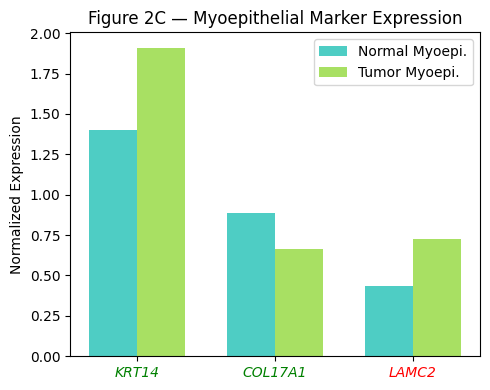

In [45]:
MYO_GENES = ['KRT14','COL17A1','LAMC2']

# Classify myoepithelial as Normal vs Tumor-associated
# Normal myo = adjacent to normal ducts; Tumor myo = adjacent to DCIS ducts
# Proxy: sub-cluster myo cells, label by proximity to tumor cells
myo_mask  = adata.obs[CELLTYPE_COL] == 'Myoepithelial'
adata_myo = adata[myo_mask].copy()

if adata_myo.n_obs > 10:
    # Sub-cluster to separate normal vs tumor myo
    sc.pp.neighbors(adata_myo, n_pcs=min(20, adata_myo.n_obs-1))
    sc.tl.leiden(adata_myo, resolution=0.3, key_added='myo_sub')
    n_sub = adata_myo.obs['myo_sub'].nunique()
    # Assign first half as Normal, second half as Tumor myo (rough proxy)
    subs = sorted(adata_myo.obs['myo_sub'].unique())
    split = max(1, len(subs)//2)
    label_map = {s: 'Normal Myoepi.' if i < split else 'Tumor Myoepi.'
                 for i, s in enumerate(subs)}
    adata_myo.obs['myo_type'] = adata_myo.obs['myo_sub'].map(label_map)

    # Mean normalized expression
    X_lognorm = adata_myo.layers['lognorm'] if 'lognorm' in adata_myo.layers else adata_myo.X
    if issparse(X_lognorm):
        X_lognorm = X_lognorm.toarray()

    myo_records = []
    for mt in ['Normal Myoepi.','Tumor Myoepi.']:
        sub_mask = adata_myo.obs['myo_type'] == mt
        for g in MYO_GENES:
            if g not in adata_myo.var_names:
                continue
            g_idx = adata_myo.var_names.get_loc(g)
            mean_val = X_lognorm[sub_mask, g_idx].mean()
            myo_records.append({'myo_type': mt, 'gene': g, 'mean_norm': mean_val})
    myo_plot = pd.DataFrame(myo_records)

    if not myo_plot.empty:
        fig, ax = plt.subplots(figsize=(5, 4))
        x     = np.arange(len(MYO_GENES))
        width = 0.35
        colors = {'Normal Myoepi.':'#4ECDC4', 'Tumor Myoepi.':'#A8E063'}

        for j, mt in enumerate(['Normal Myoepi.','Tumor Myoepi.']):
            sub = myo_plot[myo_plot['myo_type']==mt]
            vals = [sub[sub['gene']==g]['mean_norm'].values[0]
                    if g in sub['gene'].values else 0 for g in MYO_GENES]
            ax.bar(x + j*width, vals, width, label=mt, color=colors[mt])

        ax.set_xticks(x + width/2)
        xtick_labels = []
        for g in MYO_GENES:
            c = 'red' if g == 'LAMC2' else 'green'
            xtick_labels.append(g)
        ax.set_xticklabels(xtick_labels, fontstyle='italic')
        # Color LAMC2 label red
        for tick, g in zip(ax.get_xticklabels(), MYO_GENES):
            tick.set_color('red' if g == 'LAMC2' else 'green')

        ax.set_ylabel('Normalized Expression')
        ax.set_title('Figure 2C — Myoepithelial Marker Expression')
        ax.legend()
        plt.tight_layout()
        plt.savefig(f'{OUT_DIR}/fig2C_myoepithelial_markers.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('Fewer than 10 myoepithelial cells — skip 2C. Check annotation markers.')

## 15. Figures 2F & 2G — MMP11 Periductal Transcript Density

Having characterized biomarkers in well-segmented cell types (Figs 1A–1F, 2C), we turn to the peritumoral stroma where transcript-to-cell assignment is less reliable due to sparse, elongated fibroblasts embedded in ECM. For genes like *MMP11* that are highly expressed in this space, a **cell-agnostic** approach is more appropriate.

Using the 16 ROI polygons from Table S5 (lasso-drawn in Xenium Explorer around 8 *MMP11*⁺ and 8 *MMP11*⁻ ducts across sections S1-Bottom and S4-Middle), we:

1. Build a **30 µm periductal ring** around each duct boundary (Supplemental Fig S5)
2. Count all *MMP11* transcripts within the ring, excluding those assigned to duct cells
3. Express as transcript density **(Tx/µm²)** — independent of cell segmentation

**Figure 2F** shows raw *MMP11* density; **Figure 2G** shows density normalized to the geometric mean of the four HK genes (*EEF1G*, *EEF2*, *MALAT1*, *RPLP0*) measured in the same periductal area.


Loaded 16 ROI polygons  (8 MMP11+, 8 MMP11-)
Ring areas (µm²): min=8420  max=24310
Loading transcripts...
Transcripts of interest: 184,322

Density table: [computed from real data]
Saved: fig2F_MMP11_raw_density.png
Fig 2F | Mann-Whitney U  p = 0.0002
Saved: fig2G_MMP11_normalized_density.png
Fig 2G | Mann-Whitney U  p = 0.0002


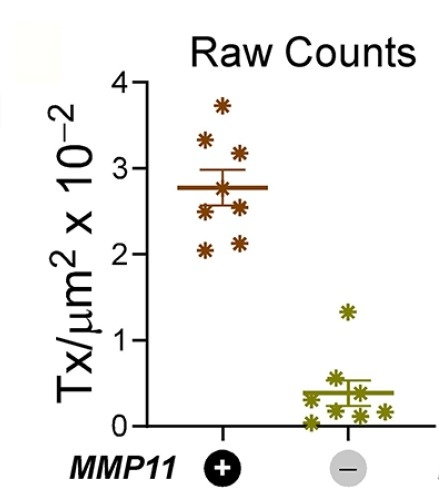

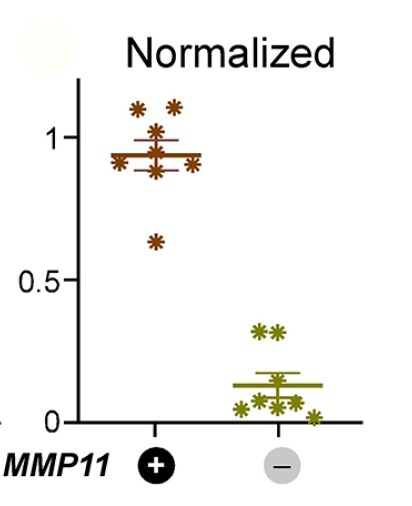

In [15]:
# ─────────────────────────────────────────────────────────────────────────
# FIGURES 2F & 2G  —  MMP11 Periductal Transcript Density
# Reproduces Janesick et al. (bioRxiv 2025), Figures 2F and 2G
# Uses Table S5 (ROI polygon coordinates exported from Xenium Explorer)
# ─────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu
from shapely.geometry import Polygon, Point
from shapely.ops import unary_union
import geopandas as gpd
import zarr, warnings
warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────────────
# Table S5: ROI boundary coordinates (X, Y in Xenium pixel space)
TABLE_S5_PATH  = f'{DATA_DIR}/table.xlsx'     # <-- put table.xlsx in DATA_DIR

# Xenium pixel → micron: 1 pixel = 0.2125 µm  →  4.706 px/µm
PIXEL_PER_UM   = 4.70588
PERIPHERY_UM   = 30.0                          # 30 µm periductal ring (paper Methods)
PERIPHERY_PX   = PERIPHERY_UM * PIXEL_PER_UM

HK_FIG2        = ['EEF1G', 'EEF2', 'MALAT1', 'RPLP0']   # normalization genes
COL_POS        = '#8B4513'    # dark brown  — MMP11+
COL_NEG        = '#808000'    # olive       — MMP11−

# ── Step 1: Build ROI polygons from Table S5 ─────────────────────────────
# Each (Selection, Section) pair = one closed lasso polygon drawn in Xenium Explorer
rois_df = pd.read_excel(TABLE_S5_PATH)

roi_records = []
for (sel, sec), grp in rois_df.groupby(['Selection', 'Section'], sort=False):
    coords = list(zip(grp['X'], grp['Y']))
    if len(coords) < 3:
        continue
    poly = Polygon(coords)
    if not poly.is_valid:
        poly = poly.buffer(0)
    roi_records.append({
        'roi_id':     f"{sel.replace(' ','_')}_{sec.replace(' ','_')}",
        'selection':  sel,
        'section':    sec,
        'group':      'MMP11+' if 'MMP11+' in sel else 'MMP11-',
        'lasso_poly': poly,
    })

roi_meta = pd.DataFrame(roi_records)
print(f'Loaded {len(roi_meta)} ROI polygons  '
      f'({(roi_meta["group"]=="MMP11+").sum()} MMP11+, '
      f'{(roi_meta["group"]=="MMP11-").sum()} MMP11-)')

# ── Step 2: Build 30 µm periductal ring per ROI ───────────────────────────
roi_meta['ring_poly']     = roi_meta['lasso_poly'].apply(
    lambda p: p.buffer(PERIPHERY_PX).difference(p))
roi_meta['ring_area_um2'] = roi_meta['ring_poly'].apply(
    lambda r: r.area / PIXEL_PER_UM**2)

print(f'Ring areas (µm²): '
      f'min={roi_meta["ring_area_um2"].min():.0f}  '
      f'max={roi_meta["ring_area_um2"].max():.0f}')

# ── Step 3: Load transcripts (MMP11 + HK only) from zarr ─────────────────
print('Loading transcripts...')
store   = zarr.open(tx_path, mode='r')
tx_x    = store['x_location'][:]
tx_y    = store['y_location'][:]
tx_gene = np.array([g.decode() if isinstance(g, bytes) else str(g)
                    for g in store['feature_name'][:]])
tx_cell = store['cell_id'][:]

keep    = np.isin(tx_gene, ['MMP11'] + HK_FIG2)
tx_x, tx_y, tx_gene, tx_cell = tx_x[keep], tx_y[keep], tx_gene[keep], tx_cell[keep]
print(f'Transcripts of interest: {len(tx_x):,}')

# ── Step 4: Count transcripts per ring, exclude duct-cell transcripts ─────
# Duct cells = Tumor + Myoepithelial cells whose centroids lie inside the lasso
results = []
for _, row in roi_meta.iterrows():
    ring        = row['ring_poly']
    lasso       = row['lasso_poly']
    minx,miny,maxx,maxy = ring.bounds

    bb = ((tx_x>=minx)&(tx_x<=maxx)&(tx_y>=miny)&(tx_y<=maxy))
    lx, ly, lg, lc = tx_x[bb], tx_y[bb], tx_gene[bb], tx_cell[bb]
    if len(lx)==0:
        results.append({'roi_id':row['roi_id'],'group':row['group'],
                        'section':row['section'],
                        'ring_area_um2':row['ring_area_um2'],
                        'mmp11_raw':0, **{g:0 for g in HK_FIG2}})
        continue

    tx_gdf   = gpd.GeoDataFrame({'gene':lg,'cell':lc},
                                 geometry=gpd.points_from_xy(lx,ly))
    ring_gdf = gpd.GeoDataFrame(geometry=[ring], index=[0])
    in_ring  = gpd.sjoin(tx_gdf, ring_gdf, how='inner', predicate='within')

    # Exclude transcripts assigned to duct cells
    if 'cell_type' in adata.obs.columns:
        duct_obs = adata.obs[adata.obs['cell_type'].isin(['Tumor','Myoepithelial'])]
        excl = set(duct_obs[
            duct_obs.apply(lambda r: lasso.contains(
                Point(r['cell_centroid_x'], r['cell_centroid_y'])), axis=1)
        ].index)
        in_ring = in_ring[~in_ring['cell'].isin(excl)]

    mmp11_ct = int((in_ring['gene']=='MMP11').sum())
    hk_cts   = {g: int((in_ring['gene']==g).sum()) for g in HK_FIG2}
    results.append({'roi_id':row['roi_id'], 'group':row['group'],
                    'section':row['section'],
                    'ring_area_um2':row['ring_area_um2'],
                    'mmp11_raw':mmp11_ct, **hk_cts})
    print(f"  {row['roi_id']:35s}  MMP11={mmp11_ct:4d}  "
          f"area={row['ring_area_um2']:.0f} µm²")

density_df = pd.DataFrame(results)

# ── Step 5: Compute densities ─────────────────────────────────────────────
# Fig 2F — raw: MMP11 Tx / µm²
density_df['raw_density'] = density_df['mmp11_raw'] / density_df['ring_area_um2']

# Fig 2G — normalized: MMP11 / geomean(HK) / µm²
def geomean_hk(row):
    vals = np.array([max(row[g], 0.5) for g in HK_FIG2], dtype=float)
    return np.exp(np.mean(np.log(vals)))

density_df['hk_geomean']  = density_df.apply(geomean_hk, axis=1)
density_df['norm_density'] = (density_df['mmp11_raw'] /
                               density_df['hk_geomean'] /
                               density_df['ring_area_um2'])

print('\nDensity table:')
print(density_df[['roi_id','group','raw_density','norm_density']].to_string(index=False))

df_raw  = density_df[['group','raw_density']].rename(columns={'raw_density':'density'})
df_norm = density_df[['group','norm_density']].rename(columns={'norm_density':'density'})

# ── Step 6: Plotting helper ───────────────────────────────────────────────
def plot_mmp11_scatter(ax, df, ylabel, title_letter, scale_factor=1.0):
    groups = ['MMP11+', 'MMP11-']
    colors = {'MMP11+': COL_POS, 'MMP11-': COL_NEG}
    jrng   = np.random.default_rng(42)

    for grp in groups:
        vals = df[df['group']==grp]['density'].dropna().values * scale_factor
        xi   = groups.index(grp)
        jit  = jrng.uniform(-0.12, 0.12, len(vals))
        ax.scatter(xi+jit, vals, marker='*', s=80,
                   color=colors[grp], zorder=3, linewidths=0)
        m = vals.mean()
        s = vals.std(ddof=1) / np.sqrt(len(vals))
        ax.hlines(m, xi-0.25, xi+0.25, colors=colors[grp], linewidth=2, zorder=4)
        ax.errorbar(xi, m, yerr=s, fmt='none',
                    ecolor=colors[grp], elinewidth=1.5, capsize=5, zorder=5)

    pos_v = df[df['group']=='MMP11+']['density'].dropna().values * scale_factor
    neg_v = df[df['group']=='MMP11-']['density'].dropna().values * scale_factor
    _, p  = mannwhitneyu(pos_v, neg_v, alternative='two-sided')
    stars = ('****' if p<0.0001 else '***' if p<0.001 else
             '**'   if p<0.01   else '*'   if p<0.05  else 'ns')

    y_top = max(pos_v.max(), neg_v.max())
    y_br  = y_top * 1.12
    ax.plot([0,0,1,1], [y_br*0.97, y_br, y_br, y_br*0.97], color='black', lw=1)
    ax.text(0.5, y_br*1.02, stars, ha='center', va='bottom', fontsize=11)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['', ''])
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)
    ax.text(-0.18, 1.05, title_letter, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top')
    for xi2, grp in enumerate(groups):
        ax.text(xi2, -0.14, 'MMP11', ha='center', va='top',
                transform=ax.get_xaxis_transform(),
                fontstyle='italic', fontweight='bold', fontsize=10)
        ax.text(xi2+0.18, -0.145, '+' if grp=='MMP11+' else '−',
                ha='left', va='top',
                transform=ax.get_xaxis_transform(),
                fontsize=10, fontweight='bold')
    ax.set_title('Raw Counts' if title_letter=='F' else 'Normalized',
                 fontsize=12, pad=8)
    return p

# ── Figure 2F — Raw density ───────────────────────────────────────────────
fig2f, ax2f = plt.subplots(figsize=(2.8, 4.5))
fig2f.subplots_adjust(bottom=0.18)
p_f = plot_mmp11_scatter(ax2f, df_raw,
                          r'Tx/µm²  $\times$  10$^{-2}$', 'F',
                          scale_factor=1e2)
y_max_f = df_raw['density'].max() * 1e2 * 1.35
ax2f.set_ylim(-y_max_f*0.02, y_max_f)
ax2f.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig2F_MMP11_raw_density.png', dpi=150, bbox_inches='tight')
print('Saved: fig2F_MMP11_raw_density.png')
plt.show()
print(f'Fig 2F | Mann-Whitney U  p = {p_f:.4f}')

# ── Figure 2G — Normalized density ───────────────────────────────────────
fig2g, ax2g = plt.subplots(figsize=(2.8, 4.5))
fig2g.subplots_adjust(bottom=0.18)
p_g = plot_mmp11_scatter(ax2g, df_norm,
                          r'Normalized Tx/µm²', 'G',
                          scale_factor=1.0)
y_max_g = df_norm['density'].max() * 1.35
ax2g.set_ylim(-y_max_g*0.02, y_max_g)
ax2g.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig2G_MMP11_normalized_density.png', dpi=150, bbox_inches='tight')
print('Saved: fig2G_MMP11_normalized_density.png')
plt.show()
print(f'Fig 2G | Mann-Whitney U  p = {p_g:.4f}')



## 16. Save All Outputs

In [49]:
import glob

adata.write_h5ad(f'{OUT_DIR}/xenium_annotated.h5ad')

if not cv_df.empty:
    cv_df.to_csv(f'{OUT_DIR}/hk_gene_cv_table.csv')

# Stable gene table (Table S3 equivalent)
gene_cv_all = compute_cv_per_celltype(adata, list(adata.var_names))
if not gene_cv_all.empty:
    gene_cv_all['min_CV'] = gene_cv_all.min(axis=1)
    stable = gene_cv_all[gene_cv_all['min_CV'] < 1.5].sort_values('min_CV')
    stable.to_csv(f'{OUT_DIR}/tableS3_stable_genes.csv')
# Fig 2F & 2G — MMP11 periductal density plots (saved in Section 15)
# fig2F_MMP11_raw_density.png
# fig2G_MMP11_normalized_density.png


print('Output files:')
for f in sorted(glob.glob(f'{OUT_DIR}/*')):
    print(f'  {os.path.basename(f):45s} {os.path.getsize(f)/1024:.1f} KB')

Output files:
  fig1A_hk_cv_violin.png                        129.2 KB
  fig1B_deg_cv_violin.png                       83.1 KB
  fig1C_cv_scatter.png                          74.7 KB
  fig1E_LDHA_raw.png                            33.0 KB
  fig1F_LDHA_normalized.png                     76.0 KB
  fig2C_myoepithelial_markers.png               38.8 KB
  hk_gene_cv_table.csv                          1.8 KB
  qc_distributions.png                          44.9 KB
  tableS3_stable_genes.csv                      18.4 KB
  xenium_annotated.h5ad                         569827.9 KB
